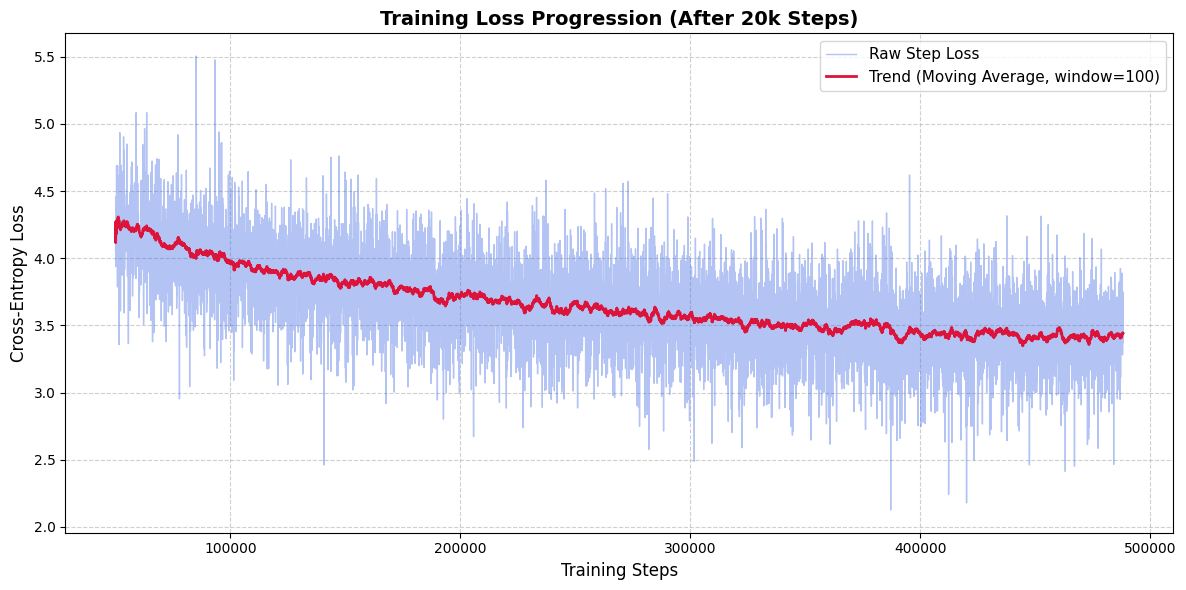

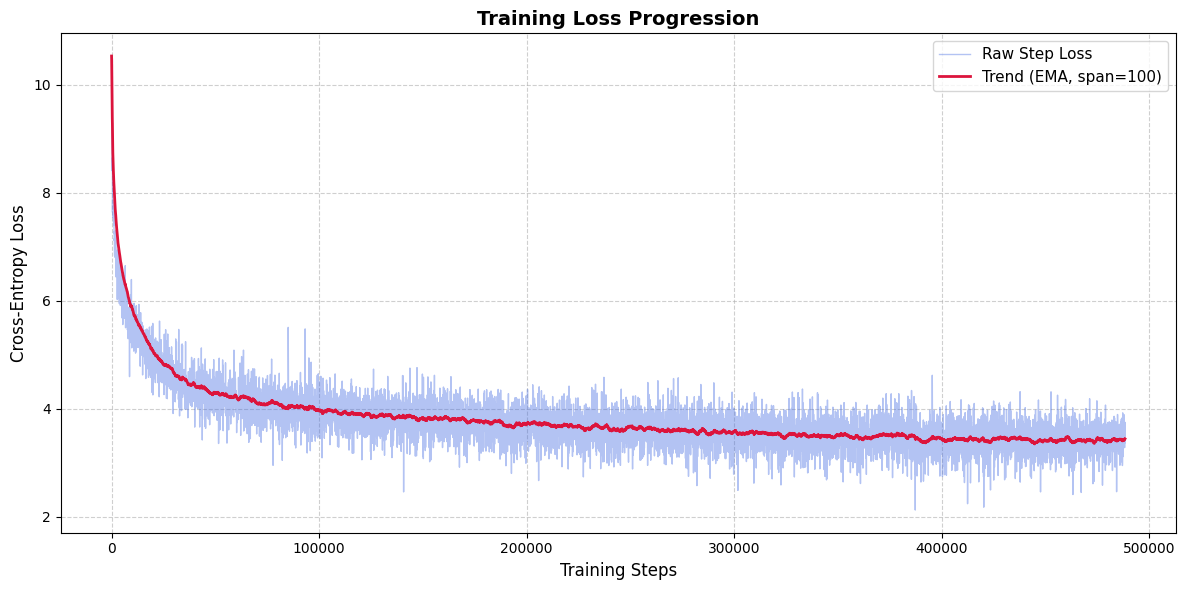

steps: 0 to 488250
losses: [10.3858, 9.859, 9.3779, 9.0481, 8.9135, 8.6982, 8.404, 8.6482, 7.6358, 7.8692, 7.542, 7.6682, 7.7583, 7.8105] to... [3.6244, 3.2905, 3.582, 3.7537, 3.3094, 3.889, 3.5015, 3.4846, 3.57, 3.6345, 3.2803, 3.5689, 3.4381, 3.75]


In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the checkpoint file
checkpoint_path = "checkpoints/pretrain_125M_phase_2/last.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# 2. Extract the loss history list
loss_history = checkpoint.get("loss_history", [])

if not loss_history:
    print("No loss history found in this checkpoint yet. Run a few steps first!")
else:
    # 3. Separate steps and loss values
    steps = [item["step"] for item in loss_history]
    losses = [item["loss"] for item in loss_history]

    steps_as = steps[50000//50:]
    losses_as = losses[50000//50:]

    losses_series = pd.Series(losses)
    losses_as_series = pd.Series(losses_as) 
    

    # Replace the rolling mean with an Exponential Moving Average (EMA)
    span_val = max(2, min(100, len(losses) // 10))
    smoothed_losses = losses_series.ewm(span=span_val).mean().tolist()
    smoothed_losses_as = losses_as_series.ewm(span=span_val).mean().tolist()
    # smoothed_losses = losses_series.rolling(window=window_size, min_periods=window_size).mean().tolist()

    # 5. Plot the perfectly aligned curves
    plt.figure(figsize=(12, 6))

    plt.plot(steps_as, losses_as, label="Raw Step Loss", color="royalblue", alpha=0.4, linewidth=1)
    plt.plot(steps_as, smoothed_losses_as, label=f"Trend (Moving Average, window={span_val})", color="crimson", linewidth=2)

    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.title("Training Loss Progression (After 20k Steps)", fontsize=14, fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))


    plt.plot(steps, losses, label="Raw Step Loss", color="royalblue", alpha=0.4, linewidth=1)
    plt.plot(steps, smoothed_losses, label=f"Trend (EMA, span={span_val})", color="crimson", linewidth=2)

    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.title("Training Loss Progression", fontsize=14, fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

print("steps:", steps[0], "to" , steps[-1])
print("losses:", losses[1:15], "to..." , losses[-15:-1])
#print(losses)